<a href="https://colab.research.google.com/github/elhartw/ML4CHEM/blob/main/EDA_BBBP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Packages installeren

In [2]:
!pip install transformers datasets rdkit scikit-learn pandas numpy matplotlib seaborn torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 23.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch versie: 2.10.0+cu128
GPU beschikbaar: True
GPU: Tesla T4


Data inladen

In [4]:
from google.colab import files
df = pd.read_csv("BBBP.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2050, 4)


,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


Exploratory data analysis

In [5]:
# Basic info about the dataset
print("=== Dataset Info ===")
print(df.info())
print("\n=== First few rows ===")
print(df.head())
print("\n=== Missing values ===")
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   num     2050 non-null   int64 
 1   name    2050 non-null   object
 2   p_np    2050 non-null   int64 
 3   smiles  2050 non-null   object
dtypes: int64(2), object(2)
memory usage: 64.2+ KB
None

=== First few rows ===
   num                  name  p_np  \
0    1            Propanolol     1   
1    2  Terbutylchlorambucil     1   
2    3                 40730     1   
3    4                    24     1   
4    5           cloxacillin     1   

                                              smiles  
0                   [Cl].CC(C)NCC(O)COc1cccc2ccccc12  
1           C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl  
2  c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...  
3                   C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C  
4  Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...  

=== Missing value

Class divide:
p_np
1    1567
0     483
Name: count, dtype: int64

Ratio positive/negative: 1567/483 = 3.24


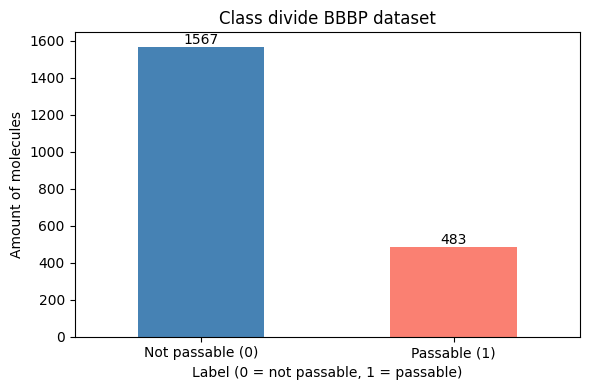

In [6]:
# Class balance
label_col = "p_np"  # 1 = passes BBB, 0 = does not pass

counts = df[label_col].value_counts()
print("Class divide:")
print(counts)
print(f"\nRatio positive/negative: {counts[1]}/{counts[0]} = {counts[1]/counts[0]:.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", color=["steelblue", "salmon"], ax=ax)
ax.set_title("Class divide BBBP dataset")
ax.set_xlabel("Label (0 = not passable, 1 = passable)")
ax.set_ylabel("Amount of molecules")
ax.set_xticklabels(["Not passable (0)", "Passable (1)"], rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()